## Exploratory Data Analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("merged_players.csv", low_memory=False)
print(f"Shape: {df.shape}")
print(f"Seasons: {df['year'].min()} to {df['year'].max()}")
print(f"Teams: {df['team'].nunique()}")
print(f"Players: {df['player_id'].nunique()}")


Shape: (25477, 69)
Seasons: 1983 to 2025
Teams: 20
Players: 3108


## Q1: Which teams have played the most games?

**Business question:** Which AFL clubs have accumulated the most total games played across all seasons?

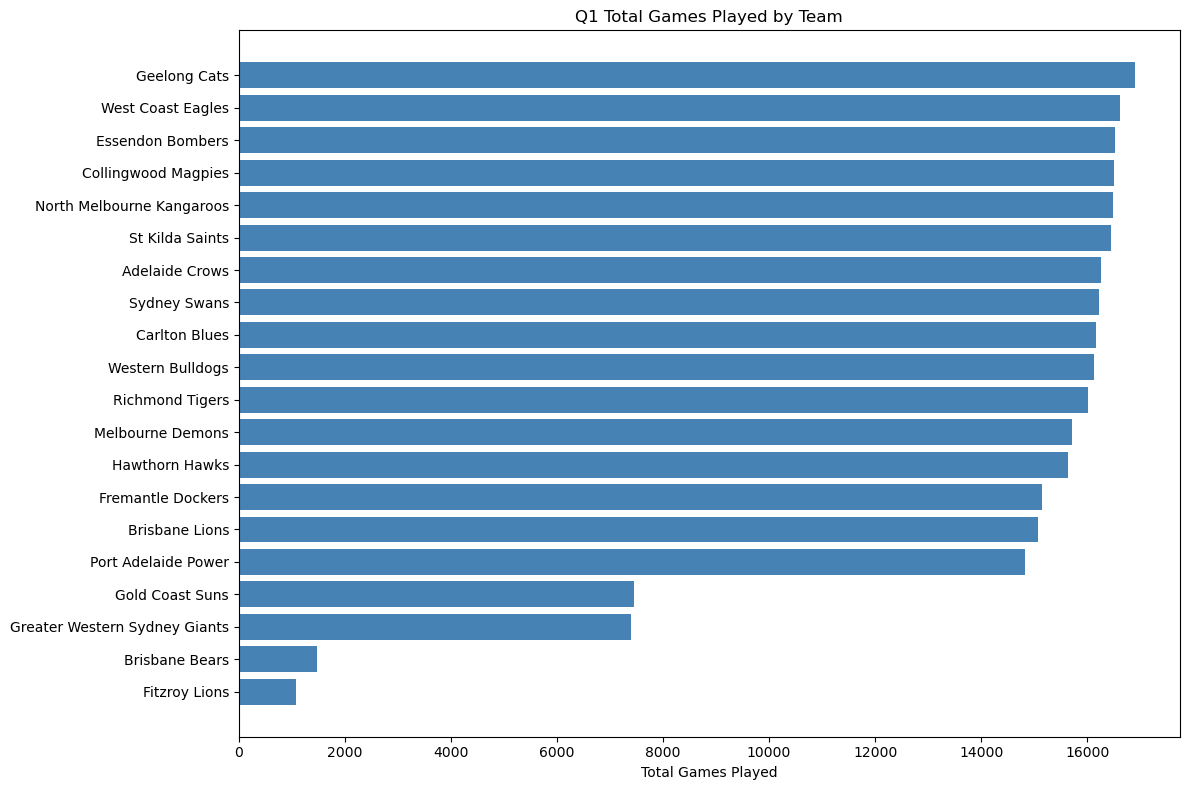

In [6]:
team_games = df.groupby("team")["games_played"].sum().sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(team_games.index, team_games.values, color="steelblue")
ax.set_xlabel("Total Games Played")
ax.set_title("Q1 Total Games Played by Team")
plt.tight_layout()
plt.savefig("charts/Q1_games_by_team.png", dpi=150)
plt.show()


**Observations**
1. Geelong Cats lead with 16,902 total games, narrowly ahead of West Coast Eagles and Essendon Bombers.
2. The top 16 active clubs are closely bunched between 14,832 and 16,902, showing broadly even data coverage across the modern era.
3. Brisbane Bears and Fitzroy Lions sit far below the rest as they merged or folded in the mid-1990s and should be excluded from cross-club comparisons.

**Business Insight:** The tight grouping of active clubs means the dataset is well-balanced for team-level analysis. Legacy clubs should be filtered out before any fair ranking or benchmarking work.


## Q2: What is the distribution of player ages (`last_age`)?

**Business question:** How old are AFL players when they play their final season? This helps clubs plan succession and understand career longevity.


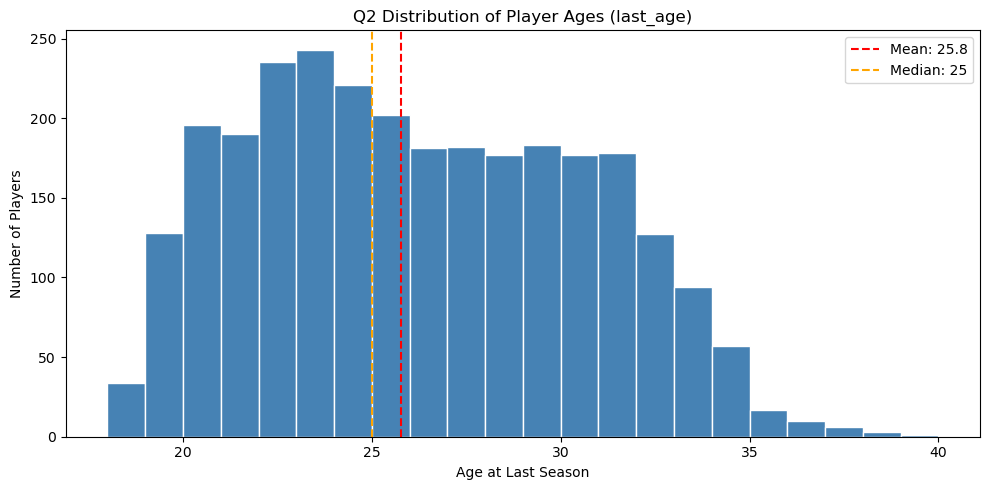

count    2842.0
mean       25.8
std         4.3
min        18.0
25%        22.0
50%        25.0
75%        29.0
max        40.0
Name: last_age, dtype: float64


In [7]:
ages = df[["player_id", "last_age"]].drop_duplicates("player_id")["last_age"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ages, bins=22, color="steelblue", edgecolor="white")
ax.axvline(ages.mean(), color="red", linestyle="--", label=f"Mean: {ages.mean():.1f}")
ax.axvline(ages.median(), color="orange", linestyle="--", label=f"Median: {ages.median():.0f}")
ax.set_xlabel("Age at Last Season")
ax.set_ylabel("Number of Players")
ax.set_title("Q2 Distribution of Player Ages (last_age)")
ax.legend()
plt.tight_layout()
plt.savefig("charts/Q2_player_age_distribution.png", dpi=150)
plt.show()

print(ages.describe().round(1))


**Observations**
1. The distribution is right-skewed with a median of 25 and mean of 25.8 which shows that most AFL players finish their career in their mid-20s, earlier than expected.
2. The interquartile range spans 22–29, meaning the middle 50% of players have their last season within a seven-year window.
3. There is a right tail extending to age 40, representing a small number of exceptional long-career players, while the peak of the distribution sits at ages 24–25.

**Business Insight:** Clubs should treat 25 as the planning trigger. The bulk of the list turns over in the early-to-mid 20s, meaning succession planning needs to start earlier than intuition suggests.

## Q3: Which teams have the highest number of players?

**Business question:** Which clubs appear most frequently in player career histories (`player_teams`)? A player who represented multiple clubs counts toward each one.


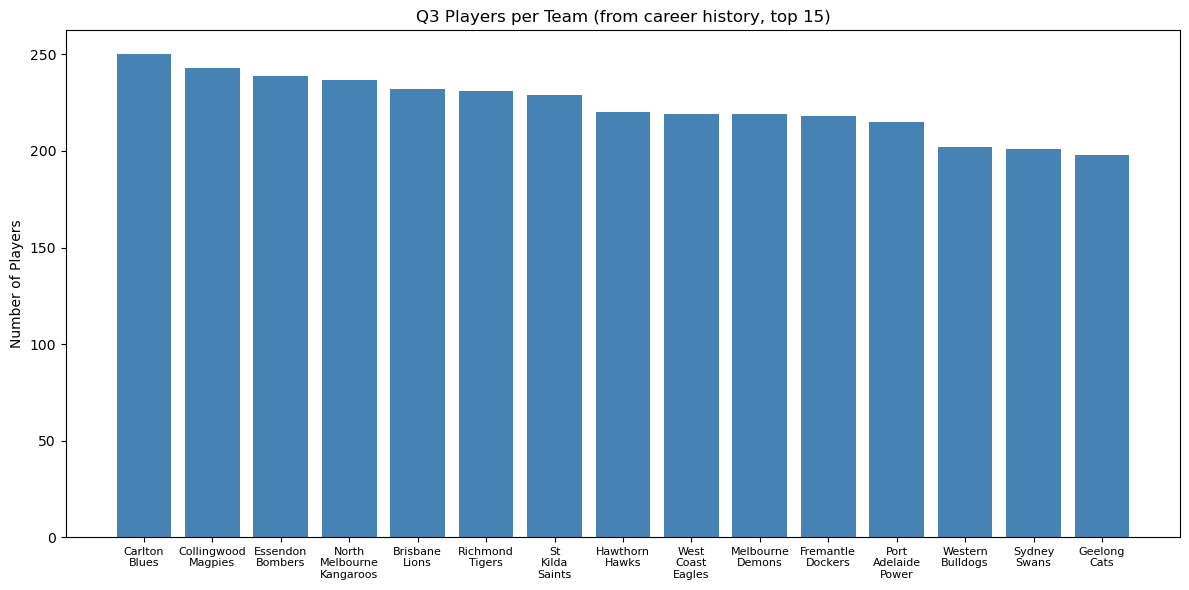

In [8]:
def parse_teams(s):
    if pd.isna(s):
        return []
    return [t.strip() for t in str(s).strip("{}").split(",") if t.strip()]

player_unique = df[["player_id", "player_teams"]].drop_duplicates("player_id")

counts = {}
for s in player_unique["player_teams"]:
    for t in parse_teams(s):
        counts[t] = counts.get(t, 0) + 1

team_counts = pd.Series(counts).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(team_counts)), team_counts.values, color="steelblue")
ax.set_xticks(range(len(team_counts)))
ax.set_xticklabels([t.replace(" ", "\n") for t in team_counts.index], fontsize=8)
ax.set_ylabel("Number of Players")
ax.set_title("Q3 Players per Team (from career history, top 15)")
plt.tight_layout()
plt.savefig("charts/Q3_players_per_team.png", dpi=150)
plt.show()


**Observations**

1. Carlton Blues lead with  almost 250 unique players, followed closely by Collingwood Magpies (245) and Essendon Bombers (240) all three are among the oldest clubs in the competition with the longest drafting history.
2. The range across all 15 clubs is very tight (198–250), confirming the AFL draft system distributes talent evenly so no club has dramatically more player throughput than another.
3. Geelong Cats sit last among the top 15 with 198 players despite being the highest game-total club (Q1), suggesting they retain players longer rather than cycling through high volumes.

**Business Insight:** Carlton's high player count reflects decades of list turnover without proportional premiership success in recent years shows that volume of players is not a predictor of performance. Geelong's low count relative to games played suggests player retention is their competitive edge.


## Q4: How does player weight vary across teams?

**Business question:** Do different clubs carry heavier or lighter playing lists? Weight spread can hint at each club's tactical style.


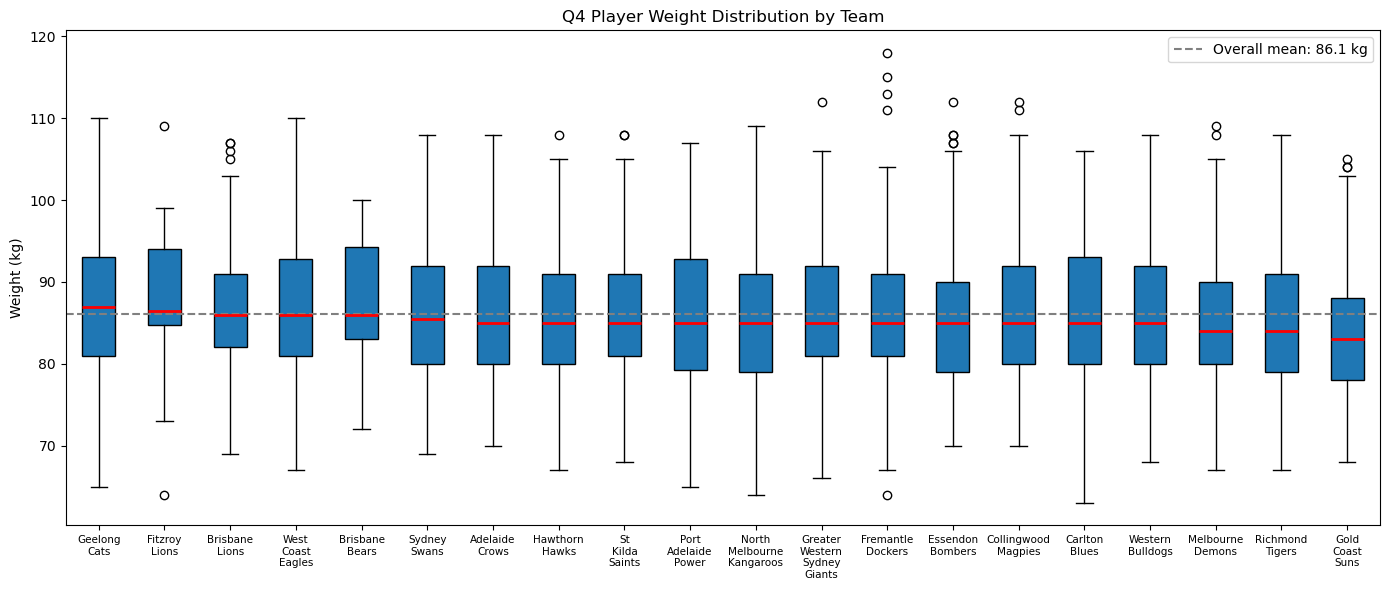

In [9]:
pw = df.dropna(subset=["weight"]).drop_duplicates("player_id")

team_order = (pw.groupby("team")["weight"]
                .median()
                .sort_values(ascending=False)
                .index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(
    [pw[pw["team"] == t]["weight"].values for t in team_order],
    tick_labels=[t.replace(" ", "\n") for t in team_order],
    patch_artist=True,
    medianprops=dict(color="red", linewidth=2)
)
ax.axhline(pw["weight"].mean(), color="grey", linestyle="--",
           label=f"Overall mean: {pw['weight'].mean():.1f} kg")
ax.set_ylabel("Weight (kg)")
ax.set_title("Q4 Player Weight Distribution by Team")
ax.tick_params(axis="x", labelsize=7.5)
ax.legend()
plt.tight_layout()
plt.savefig("charts/Q4_weight_by_team.png", dpi=150)
plt.show()


**Observations**
1. Geelong Cats have the highest median weight while Gold Coast Suns sit the lowest but the difference across the entire league is only about 4 kg, making it a very narrow spread.
2. Every team shows a wide interquartile range of roughly 10–15 kg within their own squad, meaning weight variation inside a club is far greater than variation between clubs.
3. Outliers above 105 kg (ruckmen) are visible across multiple teams, with Fremantle Dockers and Essendon Bombers showing the most extreme high-end outliers in this dataset.

**Business Insight:** Weight alone cannot differentiate club playing styles. The real story is within-squad diversity which is that every club carries the same mix of heavy key position players and light small players, so tactical differences need to be read through performance metrics, not physical attributes.

---
## Q5: Which teams have the highest average fantasy points?

**Business question:** Which clubs generate the highest average fantasy scores per season record? Fantasy points act as a composite performance proxy covering disposals, goals, marks, and tackles.


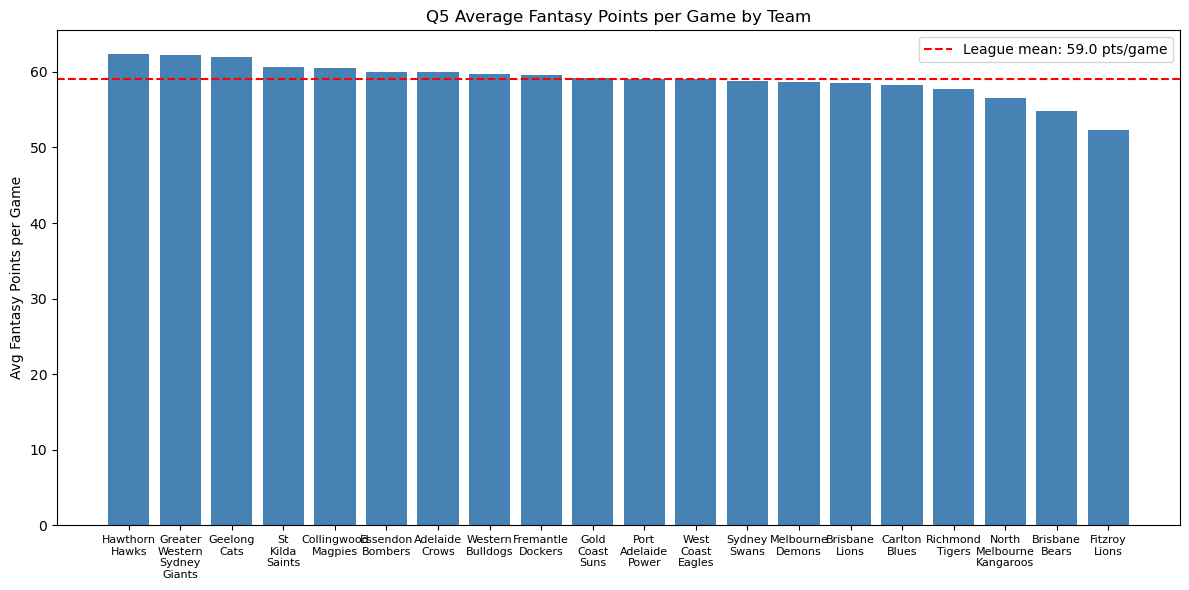

In [10]:
df['fp_per_game'] = df['total_fantasy_points'] / df['games_played']
avg_fp = df.groupby("team")["fp_per_game"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(avg_fp)), avg_fp.values, color="steelblue")
ax.set_xticks(range(len(avg_fp)))
ax.set_xticklabels([t.replace(" ", "\n") for t in avg_fp.index], fontsize=8)
ax.axhline(avg_fp.mean(), color="red", linestyle="--",
           label=f"League mean: {avg_fp.mean():.1f} pts/game")
ax.set_ylabel("Avg Fantasy Points per Game")
ax.set_title("Q5 Average Fantasy Points per Game by Team")
ax.legend()
plt.tight_layout()
plt.savefig("charts/Q5_avg_fantasy_by_team.png", dpi=150)
plt.show()

**Observations**
1. Hawthorn Hawks lead with 62.4 pts/game, consistent with their dynasty era (2008–2016) 
   built around high-disposal midfielders who score heavily in fantasy metrics.
2. The spread across all active clubs is only ~6 points (56.6–62.4), showing the AFL's 
   competitive balance keeps individual output remarkably consistent league-wide.
3. Fitzroy Lions (52.3) and Brisbane Bears (54.8) sit at the bottom as legacy clubs whose 
   records predate full fantasy stat tracking, making their averages artificially low.

**Business Insight:** Excluding legacy clubs, the active club range is
just 6 pts/game which means team-level fantasy averages are not a strong differentiator. Player-level analysis 
within a team would reveal far more meaningful performance gaps than cross-club comparisons.

## Q6: Who are the Top 15 Goal Scorers?

**Business question:** Which players have the highest cumulative goal-scoring output (sum of `avg_goals` per season) across their careers in this dataset?


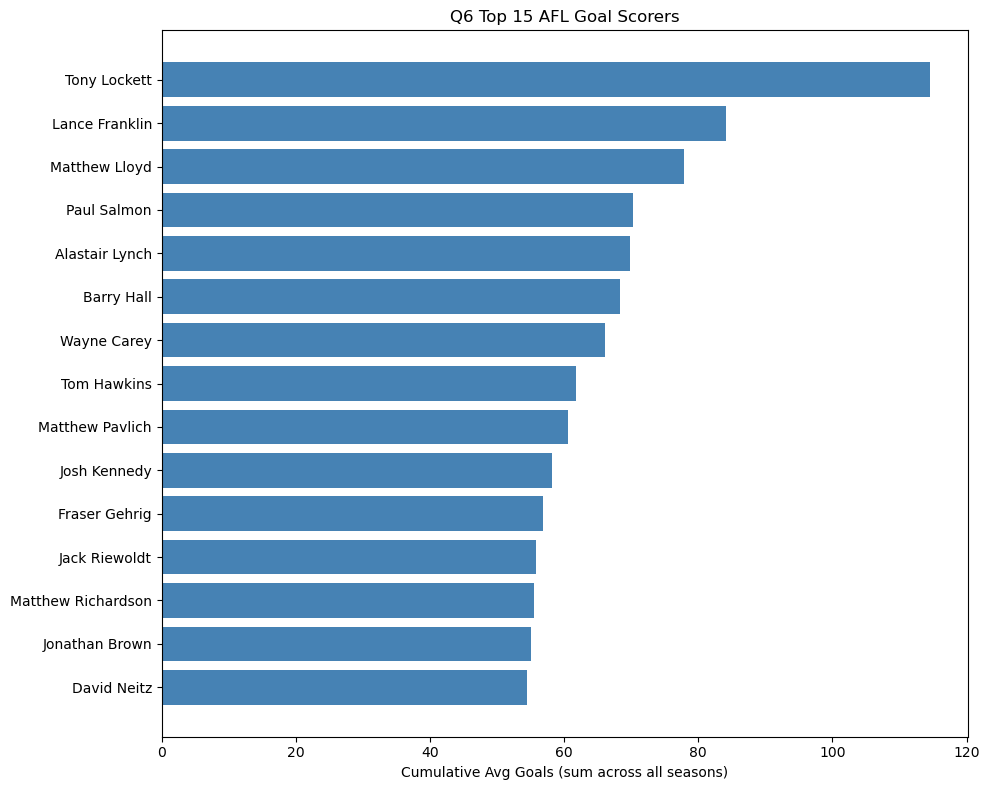

In [11]:
top15 = (df.groupby(["player_id", "player_name"])["avg_goals"]
           .sum()
           .sort_values(ascending=False)
           .head(15)
           .reset_index())

top15 = top15.sort_values("avg_goals")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top15["player_name"], top15["avg_goals"], color="steelblue")
ax.set_xlabel("Cumulative Avg Goals (sum across all seasons)")
ax.set_title("Q6 Top 15 AFL Goal Scorers")
plt.tight_layout()
plt.savefig("charts/Q6_top15_goal_scorers.png", dpi=150)
plt.show()


**Observations**
1. Tony Lockett (114.5) leads by a wide margin over Lance Franklin (84.1), reflecting both his prolific peak and the higher-scoring era he played in.
2. The list is dominated by players from the 1990s and 2000s, when the AFL produced more goals per game. Modern forwards like Tom Hawkins and Jeremy Cameron score less per game but contribute more broadly across the ground.
3. There is a clear step between the top two (Lockett, Franklin) and the rest perhaps because these two were generational goal-scorers, not just prolific ones.

**Business Insight:** Raw career goal tallies are era-dependent. Clubs evaluating modern key forwards should normalise goals against the league average for that season rather than comparing directly to pre-2010 totals.



## Q7: How many records are available for each season?

**Business question:** How does record volume change across seasons? This shows when the dataset becomes reliable enough for analysis and flags any anomalies.


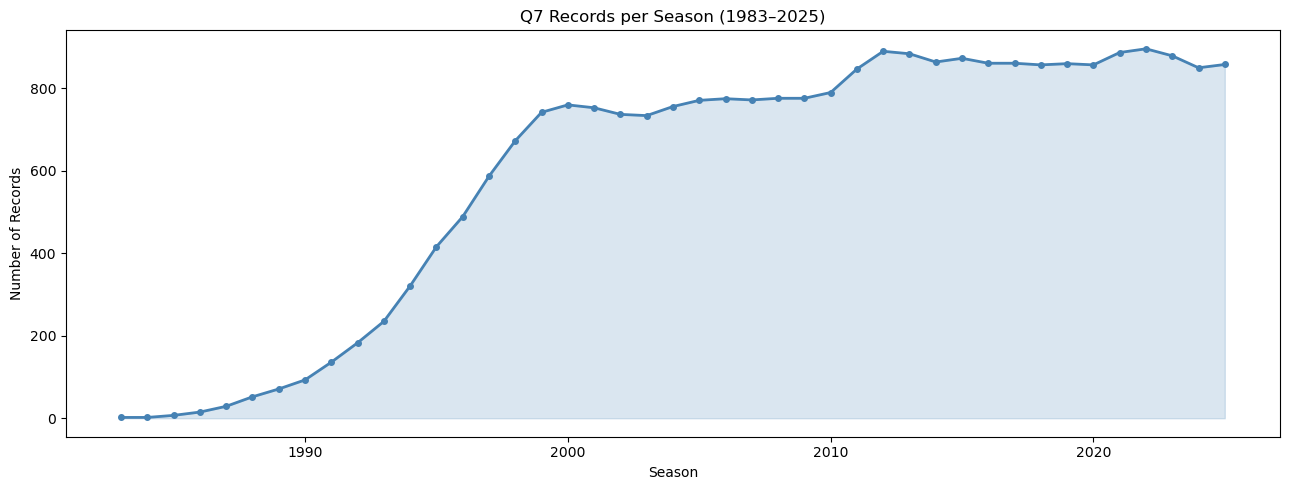

year
1983      2
1984      2
1985      7
1986     15
1987     29
1988     52
1989     71
1990     93
1991    136
1992    183
1993    235
1994    321
1995    416
1996    489
1997    587
1998    673
1999    742
2000    760
2001    753
2002    737
2003    734
2004    756
2005    771
2006    775
2007    772
2008    776
2009    776
2010    790
2011    847
2012    890
2013    884
2014    864
2015    873
2016    861
2017    861
2018    857
2019    860
2020    857
2021    887
2022    896
2023    879
2024    850
2025    858


In [12]:
rpy = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(rpy.index, rpy.values, color="steelblue", linewidth=2, marker="o", markersize=4)
ax.fill_between(rpy.index, rpy.values, alpha=0.2, color="steelblue")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Records")
ax.set_title("Q7 Records per Season (1983–2025)")
plt.tight_layout()
plt.savefig("charts/Q7_records_per_season.png", dpi=150)
plt.show()

print(rpy.to_string())


**Observations**
1. Early seasons (1983–1994) have extremely low record counts — 1983 has just 2 records 
   despite the AFL having 12 clubs at the time. This is a data collection gap, not a 
   reflection of real AFL history.
2. Records grow steadily through the 1990s as more historical data was backfilled into 
   the source, stabilising at 750–900 per season from 1999 onward.
3. 2020 shows a small dip consistent with the COVID-shortened season (17 games instead 
   of the usual 22–23).

**Business Insight:** Do not treat pre-1999 data as complete or representative of those 
actual AFL seasons. Any trend analysis comparing across eras should start from 1999 where 
coverage becomes consistent and reliable.

## Summary (5 Key Insights)

| # | Insight |
|---|---------|
| 1 | **Use 1999 as your analysis start date.** Pre-1999 records are incomplete as shown by the fact that 1983 had just 2 records despite the AFL having 12 clubs. From 1999 onward coverage is consistent at 750–900 records per season across 26 years. |
| 2 | **AFL careers typically end at 25, not 29.** The median last_age is 25 (IQR: 22–29), meaning most players are gone by their mid-20s. Clubs need to start succession planning earlier than intuition suggests. |
| 3 | **Carlton, Collingwood and Essendon have cycled through the most players (240–250) but Geelong retain theirs.** Geelong have the most games played of any club but one of the lowest player counts — their competitive edge is retention, not recruitment volume. |
| 4 | **Hawthorn lead on fantasy points per game (62.4) but the entire active league sits within a 6-point band.** Cross-club fantasy averages are not a meaningful differentiator but player-level analysis within a team tells a far more useful story. |
| 5 | **Tony Lockett's goal tally (114.5) is partly an era effect.** Pre-2010 AFL produced significantly more goals per game. Comparing modern forwards to pre-2010 totals using raw numbers will always be unfair so era-normalised metrics are needed. |